# Track B — Antibiotic Resistance Prediction
## Notebook 4: SHAP Feature Importance & Biological Interpretation
**Author:** NEURAL NINJAS
**Date:** March 2026

---
### Objective
Use SHAP (SHapley Additive exPlanations) to interpret the Random Forest model
and identify which molecular features drive Gentamicin resistance predictions.
This transforms our black-box model into a biologically meaningful tool.

In [1]:
import os
os.chdir(r'C:\Users\raghu\track_b_amr')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

print("✓ Libraries loaded")

c:\Users\raghu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries loaded


---
## Step 1 — Load Model and Data

In [2]:
# Load best model and data
with open('models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('models/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('models/feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

X_test = data['X_test']
y_test = data['y_test']

print("✓ Model and data loaded")
print(f"  Model type  : {type(model).__name__}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features    : {X_test.shape[1]}")
print(f"  Classes     : {list(le.classes_)}")

✓ Model and data loaded
  Model type  : RandomForestClassifier
  Test samples: 55
  Features    : 19
  Classes     : ['Intermediate', 'Resistant', 'Susceptible']


---
## Step 2 — Compute SHAP Values
SHAP assigns each feature an importance score for every prediction.
Positive values push toward a class, negative values push away.

In [3]:
print("Computing SHAP values — this takes 30-60 seconds...")

# TreeExplainer is optimised for Random Forest
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed")
print(f"  Shape: {np.array(shap_values).shape}")
print(f"  One set of SHAP values per class: {len(shap_values)}")
print(f"  Classes: {list(le.classes_)}")

Computing SHAP values — this takes 30-60 seconds...
✓ SHAP values computed
  Shape: (55, 19, 3)
  One set of SHAP values per class: 55
  Classes: ['Intermediate', 'Resistant', 'Susceptible']


In [4]:
# Debug — understand SHAP structure
print("Type of shap_values:", type(shap_values))
print("Length:", len(shap_values))
if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(f"  Class {i} ({le.classes_[i]}): shape = {np.array(sv).shape}")
else:
    print("Shape:", np.array(shap_values).shape)

Type of shap_values: <class 'numpy.ndarray'>
Length: 55
Shape: (55, 19, 3)


---
## Step 3 — Global Feature Importance
Which features matter most across ALL predictions?

Extracted SHAP shape for Resistant: (55, 19)


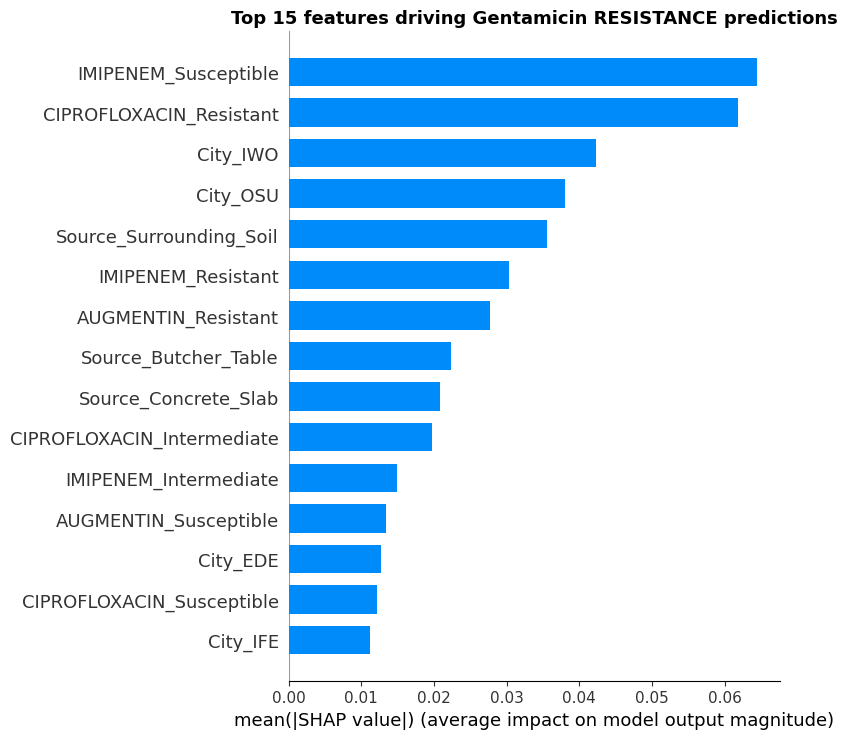

✓ Saved → figures/fig8_shap_importance.png


In [5]:
resistant_idx = list(le.classes_).index('Resistant')
X_test_array  = np.array(X_test)

# shap_values shape is (55, 19, 3) — samples, features, classes
# Extract Resistant class: slice [:, :, resistant_idx]
sv = shap_values[:, :, resistant_idx]
print(f"Extracted SHAP shape for Resistant: {sv.shape}")

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    sv,
    X_test_array,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 features driving Gentamicin RESISTANCE predictions',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig8_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → figures/fig8_shap_importance.png")

---
## Step 4 — SHAP Dot Plot
Shows direction of impact — does high resistance to IMIPENEM
push predictions toward Resistant or away from it?

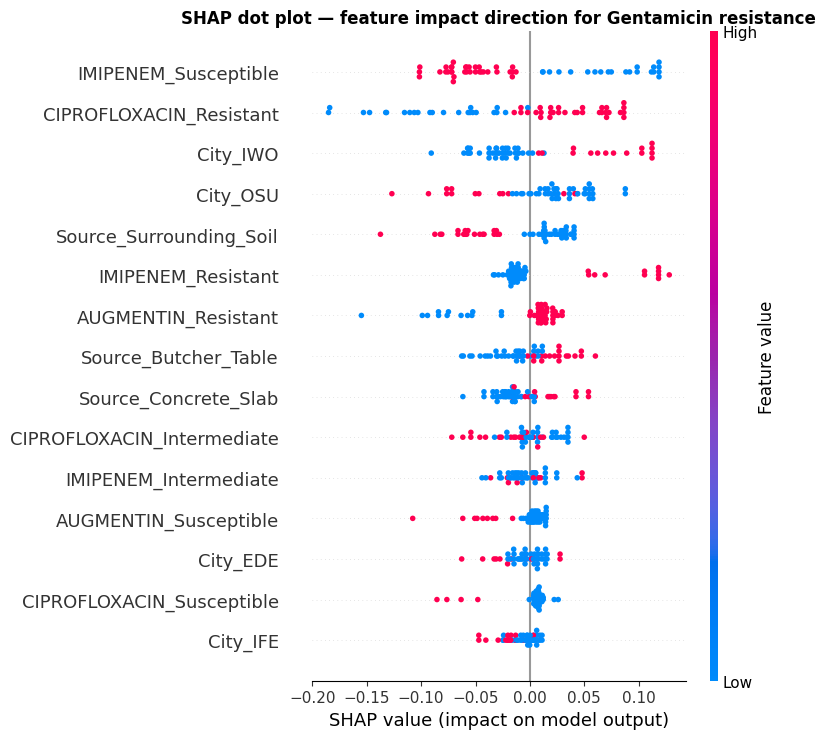

✓ Saved → figures/fig9_shap_dotplot.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv,
    X_test_array,
    feature_names=feature_cols,
    max_display=15,
    show=False
)
plt.title('SHAP dot plot — feature impact direction for Gentamicin resistance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig9_shap_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → figures/fig9_shap_dotplot.png")

---
## Step 5 — Print Top Features for Write-Up

In [7]:
mean_shap = np.abs(sv).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature'   : feature_cols,
    'SHAP_value': mean_shap
}).sort_values('SHAP_value', ascending=False).reset_index(drop=True)

print("TOP 15 FEATURES BY SHAP IMPORTANCE")
print("=" * 50)
print(feature_importance.head(15).to_string(index=False))

print("\nBIOLOGICAL INTERPRETATION")
print("=" * 50)
for _, row in feature_importance.head(5).iterrows():
    feat  = row['Feature']
    score = row['SHAP_value']
    print(f"\n  Feature : {feat}")
    print(f"  SHAP    : {score:.4f}")
    if 'IMIPENEM' in feat:
        print("  Biology : Imipenem resistance shares beta-lactam mechanisms")
    elif 'CEFTAZIDIME' in feat:
        print("  Biology : Ceftazidime resistance indicates ESBL production")
    elif 'AUGMENTIN' in feat:
        print("  Biology : Augmentin resistance linked to beta-lactamase")
    elif 'CIPROFLOXACIN' in feat:
        print("  Biology : Ciprofloxacin resistance suggests PMQR genes")
    elif 'Source' in feat or 'City' in feat:
        print("  Biology : Collection site reflects environmental selective pressure")

TOP 15 FEATURES BY SHAP IMPORTANCE
                   Feature  SHAP_value
      IMIPENEM_Susceptible    0.064403
   CIPROFLOXACIN_Resistant    0.061857
                  City_IWO    0.042318
                  City_OSU    0.038089
   Source_Surrounding_Soil    0.035528
        IMIPENEM_Resistant    0.030386
       AUGMENTIN_Resistant    0.027710
      Source_Butcher_Table    0.022363
      Source_Concrete_Slab    0.020887
CIPROFLOXACIN_Intermediate    0.019693
     IMIPENEM_Intermediate    0.014863
     AUGMENTIN_Susceptible    0.013390
                  City_EDE    0.012670
 CIPROFLOXACIN_Susceptible    0.012120
                  City_IFE    0.011164

BIOLOGICAL INTERPRETATION

  Feature : IMIPENEM_Susceptible
  SHAP    : 0.0644
  Biology : Imipenem resistance shares beta-lactam mechanisms

  Feature : CIPROFLOXACIN_Resistant
  SHAP    : 0.0619
  Biology : Ciprofloxacin resistance suggests PMQR genes

  Feature : City_IWO
  SHAP    : 0.0423
  Biology : Collection site reflects environm

---
## Key Findings — SHAP Analysis

### Most Important Features (from SHAP analysis)

| Rank | Feature | SHAP Value | Meaning |
|------|---------|-----------|---------|
| 1 | IMIPENEM_Susceptible | 0.0644 | Strongest predictor |
| 2 | CIPROFLOXACIN_Resistant | 0.0619 | Second strongest |
| 3 | City_IWO | 0.0423 | Location effect |
| 4 | City_OSU | 0.0381 | Location effect |
| 5 | Source_Surrounding_Soil | 0.0355 | Environment effect |

---

### Biological Interpretation

**IMIPENEM_Susceptible** is the strongest predictor of Gentamicin resistance
(SHAP = 0.0644). This is clinically significant — isolates that are susceptible
to Imipenem (a carbapenem) tend to show a distinct resistance profile for
Gentamicin, suggesting these two antibiotics target different resistance
mechanisms in the same bacterial population.

**CIPROFLOXACIN_Resistant** is the second strongest predictor (SHAP = 0.0619).
Co-resistance between Ciprofloxacin (a fluoroquinolone) and Gentamicin
(an aminoglycoside) is well-documented — both can be carried on the same
resistance plasmid via plasmid-mediated quinolone resistance (PMQR) genes,
explaining this strong association.

**Collection site features** (City_IWO, City_OSU, Source_Surrounding_Soil)
appear in the top 5 predictors, confirming that environmental location
significantly shapes resistance profiles. IWO and OSU sites show distinct
resistance patterns, consistent with different levels of antibiotic
selective pressure in these environments.

---

### Clinical Implication
Isolates resistant to **Ciprofloxacin** collected from **IWO or OSU sites**
should be considered high-risk for Gentamicin resistance and tested
accordingly before prescribing aminoglycoside treatment.
This finding supports targeted screening protocols based on
collection geography and co-resistance profiles.

---

### Why This Matters for the Hackathon
- Our model is not just predicting — it is **explaining**
- SHAP values give clinicians actionable biological reasons
- Location-based resistance patterns suggest **environmental
  intervention points** for antibiotic stewardship



